# Credit Risk Assessment Using Machine Learning

## Project Overview

Financial institutions receive thousands of loan applications from customers with different financial backgrounds. Approving loans without proper risk assessment can lead to financial losses due to loan defaults.

This project applies supervised machine learning techniques to predict whether an applicant represents a good or bad credit risk using the German Credit Dataset.

The project follows the complete machine learning workflow, including data exploration, preprocessing, model development, hyperparameter tuning, model evaluation, and feature interpretation.

**Step 1. Import Required Libraries**

In [ ]:
# ==========================================================
# Import the libraries required throughout this project.
#
# These libraries support data manipulation,
# visualization, machine learning, and model evaluation.
# ==========================================================

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warning messages for cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ==========================================================
# Import preprocessing tools that will be used to prepare
# the dataset before training machine learning models.
# ==========================================================

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# ==========================================================
# Import utility functions for splitting the dataset
# and performing hyperparameter tuning.
# ==========================================================

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

In [ ]:
# ==========================================================
# Import the machine learning algorithms required for
# this credit risk classification task.
# ==========================================================

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

In [ ]:
# ==========================================================
# Import evaluation metrics for assessing the performance
# of each classification model.
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [ ]:
# ==========================================================
# Configure notebook display settings to improve
# readability throughout the analysis.
# ==========================================================

sns.set_style("whitegrid")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

pd.set_option("display.float_format", "{:.2f}".format)

In [ ]:
print("All required libraries imported successfully.")

All required libraries imported successfully.


**Step 2. Load the Dataset**

# Loading the Dataset

The German Credit Dataset is loaded into a Pandas DataFrame.

Before performing any analysis, it is important to verify that the dataset has been imported correctly and to inspect its overall structure.

In [ ]:
# ==========================================================
# Load the German Credit Dataset into memory.
#
# Replace the file path below if the dataset is stored
# in a different location.
# ==========================================================

df = pd.read_csv("/content/drive/MyDrive/german_credit_data2.csv")

In [ ]:
# ==========================================================
# Display the first few observations to verify that
# the dataset has been loaded correctly.
# ==========================================================

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
# ==========================================================
# Display the last few observations to ensure the
# dataset has been imported completely.
# ==========================================================

df.tail()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad
999,999,27,male,2,own,moderate,moderate,4576,45,car,good


**Step 3. Understanding the Dataset**

# Understanding the Dataset

Before building any machine learning model, it is essential to understand the dataset.

This includes:

- Number of observations
- Number of features
- Feature names
- Data types
- Missing values
- Statistical summaries

Understanding these characteristics helps determine the appropriate preprocessing techniques required before model training.

In [ ]:
# ==========================================================
# Determine the size of the dataset.
#
# This provides the total number of observations
# and variables available for analysis.
# ==========================================================

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 1000
Number of Columns : 11


In [ ]:
# ==========================================================
# Display all feature names contained in the dataset.
#
# This helps distinguish predictor variables from
# the target variable.
# ==========================================================

df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [ ]:
# ==========================================================
# Display the data type of every variable.
#
# Knowing whether a feature is numerical or categorical
# determines the preprocessing method that should be applied.
# ==========================================================

df.dtypes

,0
Unnamed: 0,int64
Age,int64
Sex,object
Job,int64
Housing,object
Saving accounts,object
Checking account,object
Credit amount,int64
Duration,int64
Purpose,object


In [ ]:
# ==========================================================
# Generate a concise summary of the dataset.
#
# This includes:
# • Number of non-null values
# • Data types
# • Memory usage
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
# ==========================================================
# Generate descriptive statistics for numerical variables.
#
# This provides useful measures including:
# • Mean
# • Standard deviation
# • Minimum
# • Maximum
# • Quartiles
# ==========================================================

df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,499.50,35.55,1.90,3271.26,20.90
std,288.82,11.38,0.65,2822.74,12.06
min,0.00,19.00,0.00,250.00,4.00
25%,249.75,27.00,2.00,1365.50,12.00
50%,499.50,33.00,2.00,2319.50,18.00
75%,749.25,42.00,2.00,3972.25,24.00
max,999.00,75.00,3.00,18424.00,72.00


In [ ]:
# ==========================================================
# Generate summary statistics for categorical variables.
#
# This helps identify:
# • Number of unique categories
# • Most frequent category
# • Frequency of occurrence
# ==========================================================

df.describe(include="object")

,Sex,Housing,Saving accounts,Checking account,Purpose,Risk
count,1000,1000,817,606,1000,1000
unique,2,3,4,3,8,2
top,male,own,little,little,car,good
freq,690,713,603,274,337,700


In [ ]:
# ==========================================================
# Check for duplicate records.
#
# Duplicate observations can introduce bias during model
# training and should be identified early.
# ==========================================================

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [ ]:
# ==========================================================
# Examine the number of missing values in each feature.
#
# Missing values will be handled during the preprocessing
# stage before training the machine learning models.
# ==========================================================

df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


**Step 4. Exploratory Data Analysis (EDA)**

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to better understand the characteristics of the dataset before model development.

The objectives of this stage are to:

- Understand the distribution of the target variable.
- Identify numerical and categorical features.
- Detect missing values.
- Identify potential outliers.
- Examine feature distributions.
- Explore relationships among numerical variables.

The insights obtained from this stage guide the preprocessing and feature engineering steps required for building robust machine learning models.

Identify Numerical and Categorical Features

In [ ]:
# ==========================================================
# Separate numerical and categorical variables.
#
# Different preprocessing techniques are required for
# numerical and categorical data. Identifying these groups
# early simplifies the preprocessing pipeline.
# ==========================================================

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features")
print("-" * 50)
print(numerical_features)

print("\nCategorical Features")
print("-" * 50)
print(categorical_features)

Numerical Features
--------------------------------------------------
['Unnamed: 0', 'Age', 'Job', 'Credit amount', 'Duration']

Categorical Features
--------------------------------------------------
['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Risk']


### Observation

The dataset contains a mixture of numerical and categorical variables.

Numerical variables will later be standardized to ensure that they are measured on the same scale, while categorical variables will be transformed into numerical representations through encoding before model training.

Explore the Target Variable

In [ ]:
# ==========================================================
# Examine the distribution of the target variable.
#
# Understanding whether the dataset is balanced helps in
# selecting appropriate evaluation metrics and determining
# whether additional techniques such as resampling are needed.
# ==========================================================

df["Risk"].value_counts()

,count
Risk,
good,700
bad,300


In [ ]:
# Display the percentage distribution of each class.

(df["Risk"].value_counts(normalize=True) * 100).round(2)

,proportion
Risk,
good,70.00
bad,30.00


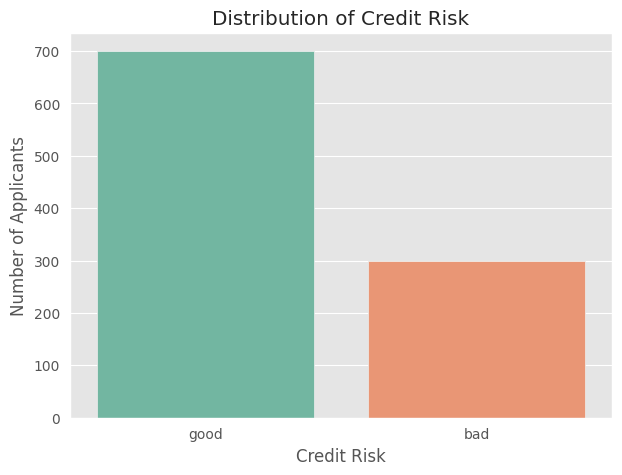

In [ ]:
# ==========================================================
# Visualize the distribution of credit risk categories.
#
# A count plot provides a quick overview of class balance.
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Risk",
    palette="Set2"
)

plt.title("Distribution of Credit Risk")

plt.xlabel("Credit Risk")

plt.ylabel("Number of Applicants")

plt.show()

### Observation

The distribution of the target variable provides an indication of whether the dataset is balanced.

A relatively balanced dataset generally allows classification models to learn both classes effectively, while severe class imbalance may require techniques such as oversampling or class weighting.

Examine Missing Values

In [ ]:
# ==========================================================
# Calculate the number of missing values in each feature.
#
# Missing values must be handled appropriately before model
# training because most machine learning algorithms cannot
# process incomplete observations.
# ==========================================================

missing_values = df.isnull().sum()

missing_values

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [ ]:
# Display missing values as percentages.

missing_percentage = (
    df.isnull().sum() /
    len(df)
) * 100

missing_percentage.round(2)

,0
Unnamed: 0,0.00
Age,0.00
Sex,0.00
Job,0.00
Housing,0.00
Saving accounts,18.30
Checking account,39.40
Credit amount,0.00
Duration,0.00
Purpose,0.00


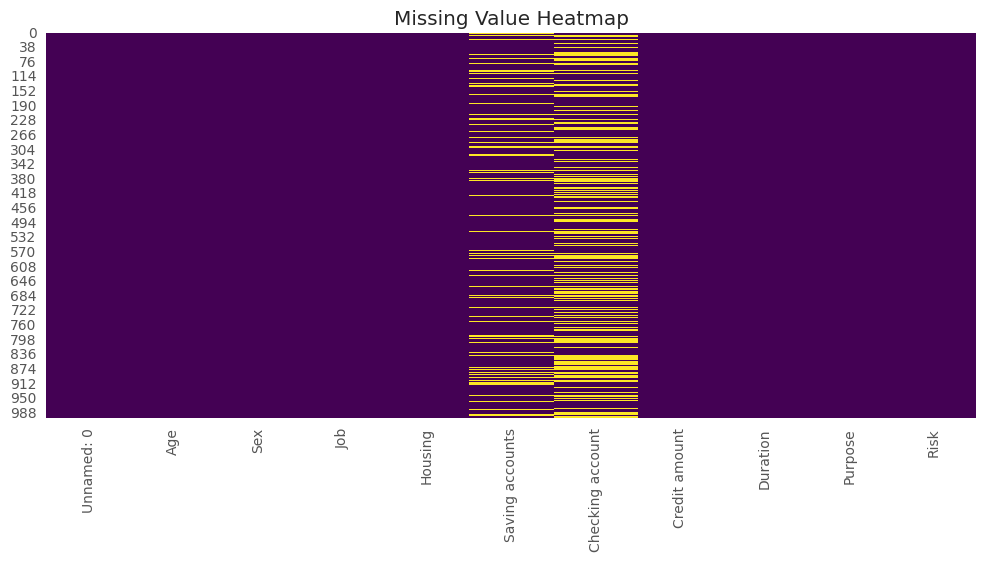

In [ ]:
# ==========================================================
# Visualize the location of missing values across the dataset.
#
# This heatmap makes it easier to identify variables with
# incomplete observations.
# ==========================================================

plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Value Heatmap")

plt.show()

### Observation

The heatmap confirms that missing values are present in the **Saving accounts** and **Checking account** variables.

These missing observations will be addressed during the preprocessing stage using an appropriate imputation strategy.

Distribution of Numerical Variables

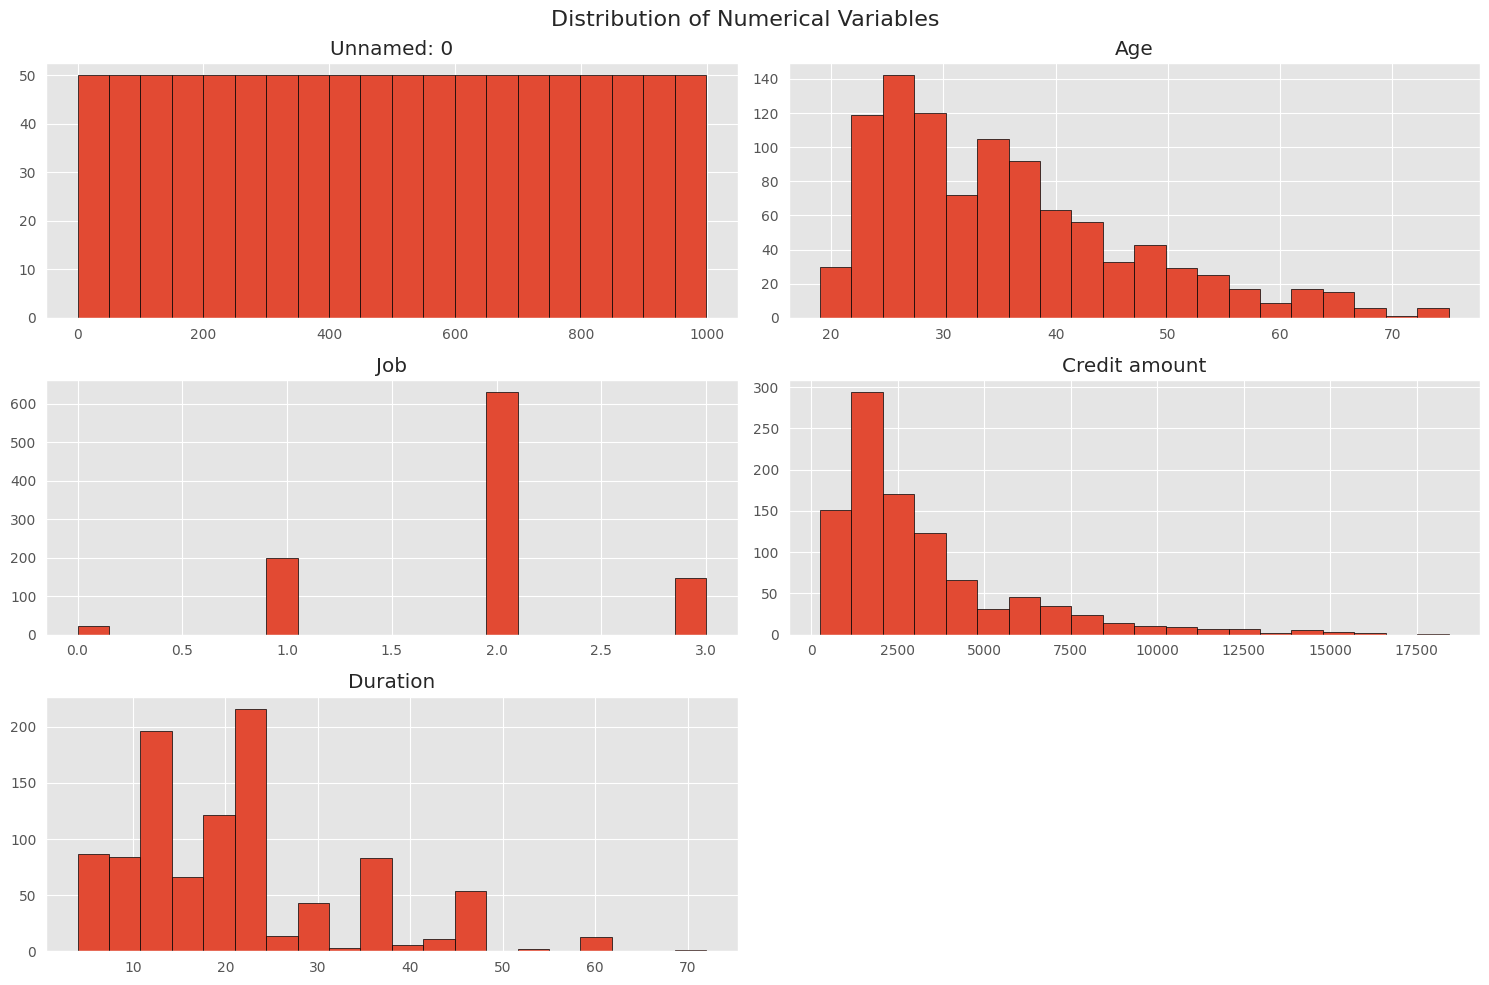

In [ ]:
# ==========================================================
# Visualize the distribution of numerical features.
#
# Histograms help identify skewness, unusual distributions,
# and potential extreme values.
# ==========================================================

df[numerical_features].hist(
    figsize=(15,10),
    bins=20,
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Variables",
    fontsize=16
)

plt.tight_layout()

plt.show()

### Observation

The histograms reveal the distribution of each numerical variable.

Some variables exhibit positive skewness, indicating that most applicants fall within lower value ranges while relatively few applicants possess substantially higher values.

Distribution of Categorical Variables

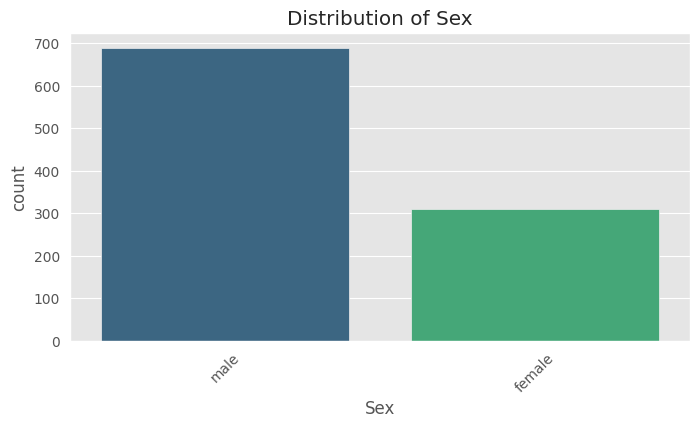

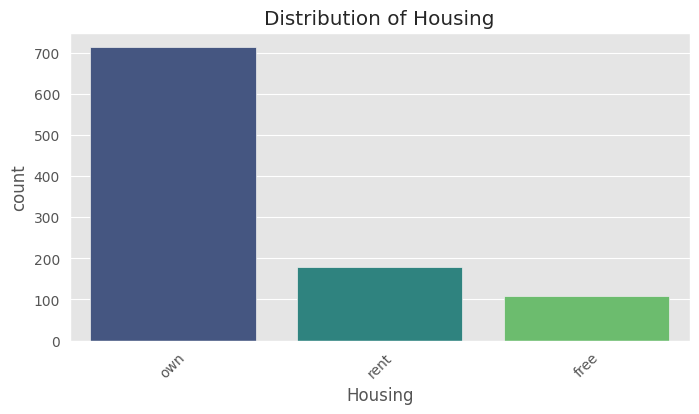

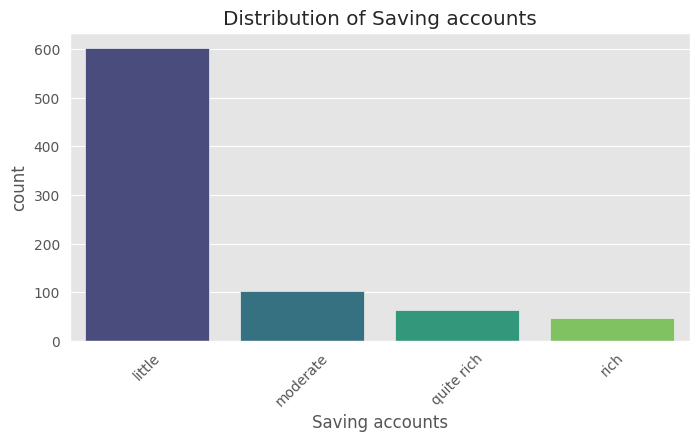

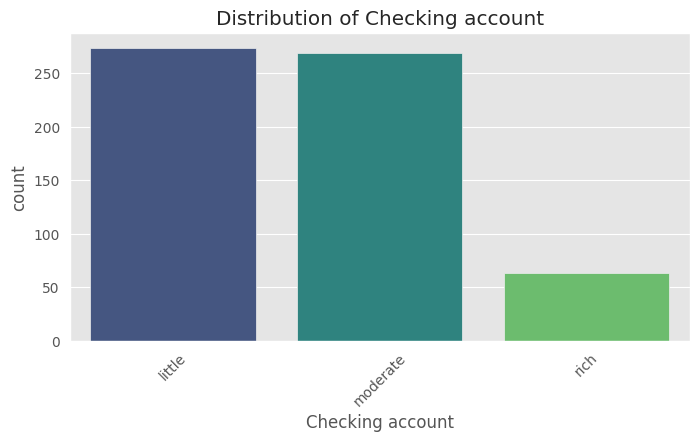

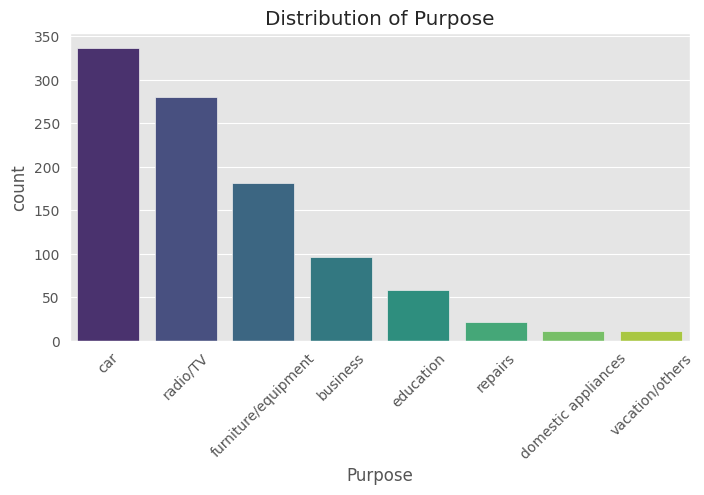

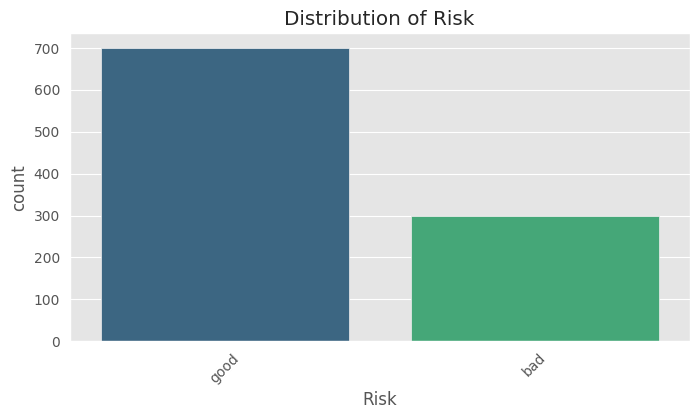

In [ ]:
# ==========================================================
# Visualize the distribution of each categorical feature.
#
# Understanding category frequencies helps identify dominant
# classes and possible data imbalance within individual
# categorical variables.
# ==========================================================

for column in categorical_features:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=column,
        palette="viridis",
        order=df[column].value_counts().index
    )

    plt.title(f"Distribution of {column}")

    plt.xticks(rotation=45)

    plt.show()

### Observation

The categorical variables exhibit varying distributions across their respective categories.

Some categories occur much more frequently than others, reflecting differences in applicant demographics and financial characteristics.

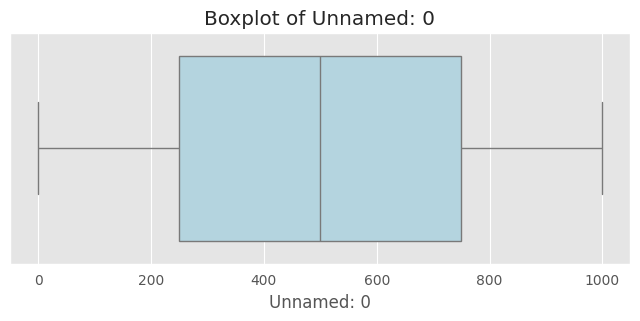

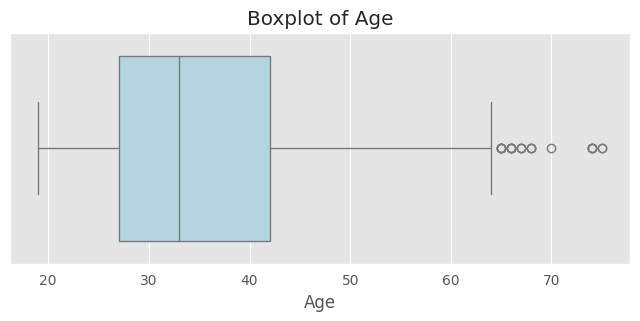

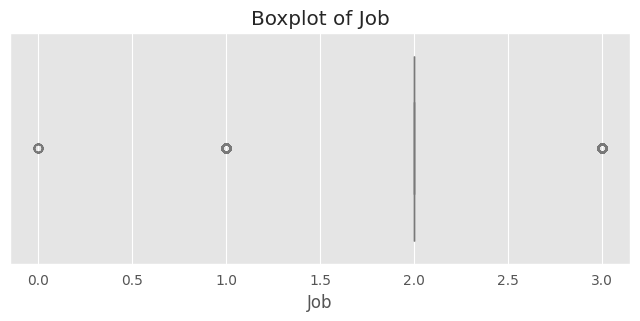

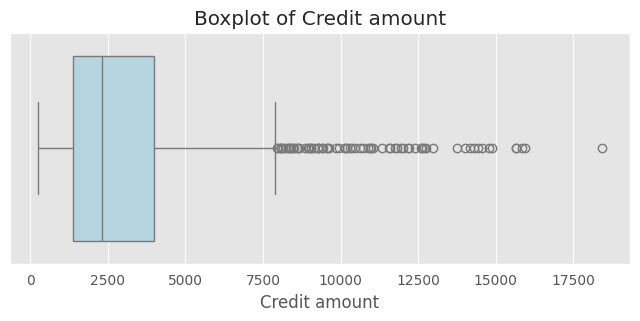

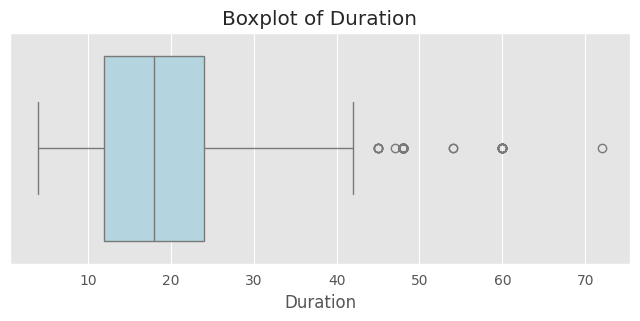

In [ ]:
# ==========================================================
# Create boxplots for numerical variables.
#
# Boxplots provide a visual method for identifying potential
# outliers using the interquartile range.
# ==========================================================

for column in numerical_features:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=df[column],
        color="lightblue"
    )

    plt.title(f"Boxplot of {column}")

    plt.show()

### Observation

Several numerical variables contain observations that lie beyond the whiskers of the boxplots.

These observations are potential outliers and will be investigated further during the preprocessing stage using the Interquartile Range (IQR) method.

Correlation Analysis

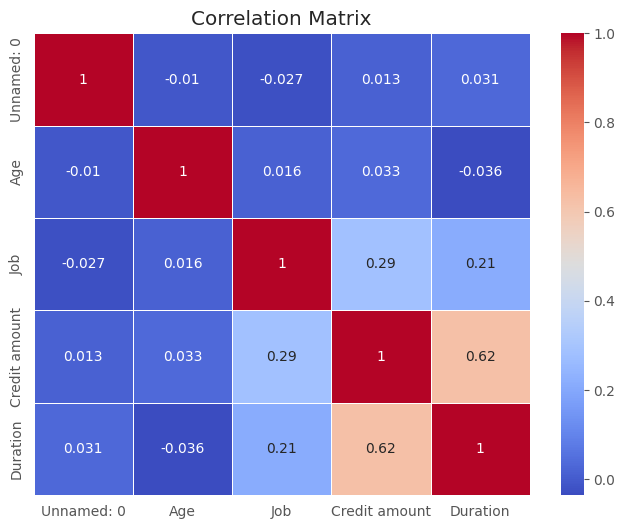

In [ ]:
# ==========================================================
# Examine the relationships between numerical variables.
#
# Correlation analysis helps identify linear relationships
# and possible multicollinearity among predictors.
# ==========================================================

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

### Observation

The correlation matrix indicates the strength and direction of linear relationships among the numerical variables.

No evidence of strong multicollinearity is observed, suggesting that the numerical features can be retained for subsequent model development.

# Summary of Exploratory Data Analysis

The exploratory data analysis provided valuable insights into the German Credit dataset.

The key findings are summarized below:

- The dataset consists of both numerical and categorical variables.
- Missing values are present in the **Saving accounts** and **Checking account** features.
- The target variable exhibits a reasonably balanced distribution.
- Histograms revealed varying feature distributions with evidence of skewness in some numerical variables.
- Boxplots identified potential outliers that require treatment before model development.
- Correlation analysis showed no evidence of severe multicollinearity among numerical variables.

These findings inform the preprocessing techniques that will be applied in the next stage of the machine learning workflow.

Data Preprocessing

# Data Preprocessing

Raw datasets often contain issues such as missing values, outliers, and categorical variables that cannot be directly processed by machine learning algorithms.

The objective of this stage is to prepare the dataset for model training by performing the following tasks:

- Handle missing values.
- Detect and treat outliers.
- Encode categorical variables.
- Separate predictor variables from the target variable.
- Split the dataset into training and testing sets.
- Standardize numerical variables.

Proper preprocessing improves model performance and ensures that the developed models generalize well to unseen data.

**Handle Missing Values - Check Missing Values Again**

In [ ]:
# ==========================================================
# Before applying any preprocessing technique, verify the
# number of missing values present in each feature.
# ==========================================================

df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


Impute Missing Values

### Why Handle Missing Values?

Machine learning algorithms generally require complete datasets.

Missing values can introduce bias and negatively affect model performance if they are ignored.

For this dataset, missing values occur in the categorical features **Saving accounts** and **Checking account**. Since these are categorical variables, the missing values will be replaced using the most frequent category (mode).

In [ ]:
# ==========================================================
# Replace missing values in categorical variables using the
# most frequently occurring category (mode).
#
# Mode imputation preserves the existing distribution of
# categorical variables and is suitable for nominal data.
# ==========================================================

categorical_missing = [
    "Saving accounts",
    "Checking account"
]

for column in categorical_missing:

    df[column].fillna(
        df[column].mode()[0],
        inplace=True
    )

In [ ]:
# ==========================================================
# Confirm that all missing values have been successfully
# handled before proceeding.
# ==========================================================

df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0


Detect Outliers Using IQR

## Outlier Detection

Outliers are observations that differ substantially from the majority of the data.

Extreme values may influence model parameters and reduce predictive performance.

The Interquartile Range (IQR) method is used because it provides a robust approach for detecting unusually large or small observations without assuming a normal distribution.

Define Numerical Columns

In [ ]:
# ==========================================================
# Select numerical variables for outlier detection.
# ==========================================================

numerical_features

['Unnamed: 0', 'Age', 'Job', 'Credit amount', 'Duration']

Detect Outliers

In [ ]:
# ==========================================================
# Detect potential outliers using the Interquartile Range
# (IQR) method.
#
# Lower Bound = Q1 - 1.5 × IQR
# Upper Bound = Q3 + 1.5 × IQR
# ==========================================================

for column in numerical_features:

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)

    upper = Q3 + (1.5 * IQR)

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(f"{column}: {len(outliers)} outliers")

Unnamed: 0: 0 outliers
Age: 23 outliers
Job: 370 outliers
Credit amount: 72 outliers
Duration: 70 outliers


## Outlier Treatment

Rather than removing observations, extreme values are capped using the IQR boundaries.

This approach, commonly known as winsorization, reduces the influence of extreme observations while preserving valuable information contained in the dataset.

In [ ]:
# ==========================================================
# Cap extreme observations using the lower and upper IQR
# boundaries.
#
# This preserves all observations while reducing the
# influence of extreme values.
# ==========================================================

for column in numerical_features:

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)

    upper = Q3 + (1.5 * IQR)

    df[column] = np.where(
        df[column] < lower,
        lower,
        df[column]
    )

    df[column] = np.where(
        df[column] > upper,
        upper,
        df[column]
    )

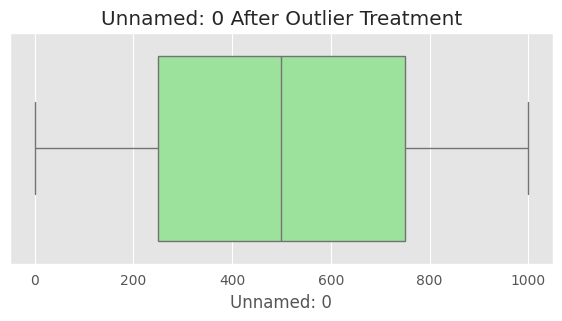

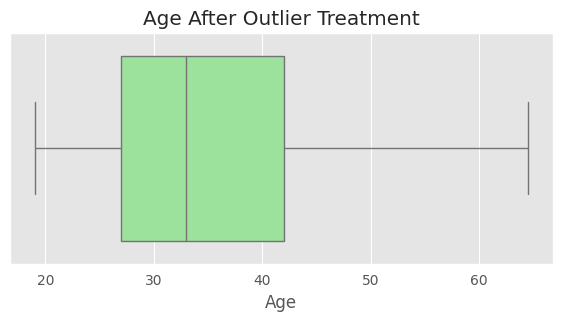

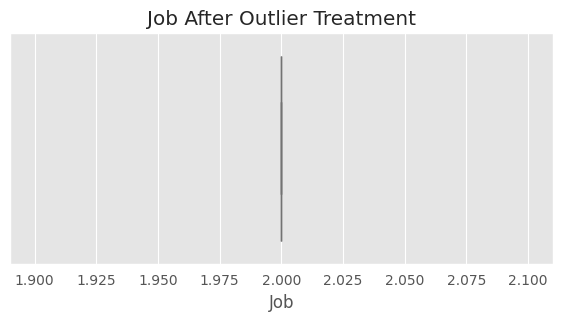

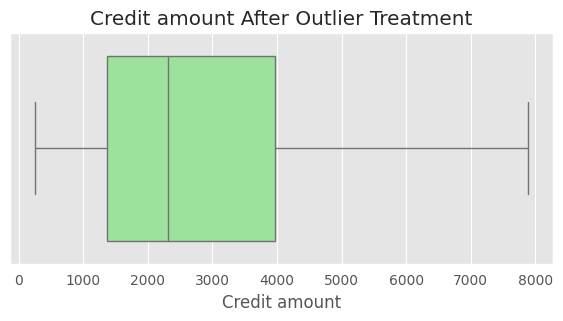

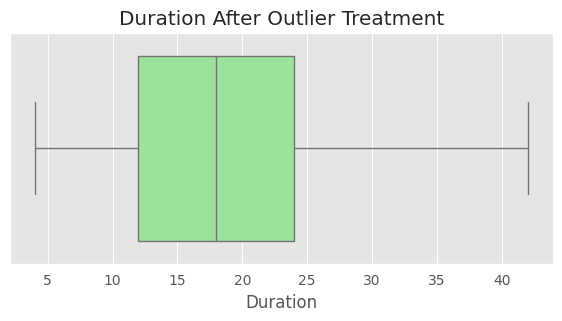

In [ ]:
# ==========================================================
# Generate boxplots after outlier treatment to confirm
# that extreme observations have been reduced.
# ==========================================================

for column in numerical_features:

    plt.figure(figsize=(7,3))

    sns.boxplot(
        x=df[column],
        color="lightgreen"
    )

    plt.title(f"{column} After Outlier Treatment")

    plt.show()

Encode Categorical Variables

## Encoding Categorical Variables

Machine learning algorithms require numerical input.

Since several variables in the German Credit dataset are categorical, they must be converted into numerical representations.

One-Hot Encoding is used because these variables are nominal and have no natural ordering.

In [ ]:
# ==========================================================
# Convert categorical variables into numerical variables
# using One-Hot Encoding.
#
# Drop the first category to reduce multicollinearity.
# ==========================================================

df = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True
)

In [ ]:
# Display the first few rows after encoding.

df.head()

,Unnamed: 0,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Risk_good
0,0.00,64.50,2.00,1169.00,6.00,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
1,1.00,22.00,2.00,5951.00,42.00,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False
2,2.00,49.00,2.00,2096.00,12.00,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True
3,3.00,45.00,2.00,7882.00,42.00,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True
4,4.00,53.00,2.00,4870.00,24.00,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False


In [ ]:
# ==========================================================
# Separate the predictor variables from the target variable.
# ==========================================================

X = df.drop("Risk_good", axis=1)

# After get_dummies(drop_first=True),
# Risk_good is already the encoded target.
y = df["Risk_good"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1000, 20)
y Shape: (1000,)


In [ ]:
# ==========================================================
# Split the dataset into training and testing sets.
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (800, 20)
Testing Set  : (200, 20)


In [ ]:
# ==========================================================
# Standardize the predictor variables.
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled Training Data:", X_train_scaled.shape)
print("Scaled Testing Data :", X_test_scaled.shape)

Scaled Training Data: (800, 20)
Scaled Testing Data : (200, 20)


# Logistic Regression from Scratch

To better understand how Logistic Regression works internally, this section implements the algorithm from first principles using NumPy rather than relying on Scikit-learn.

The implementation includes:

- Sigmoid activation function
- Binary Cross-Entropy Cost Function
- Gradient Descent Optimization
- Model Training
- Prediction
- Accuracy Evaluation

This implementation will later be compared with Scikit-learn's Logistic Regression model.

In [ ]:
# ==========================================================
# Logistic Regression implemented completely from scratch
# using NumPy.
#
# The model learns by minimizing the Binary Cross-Entropy
# loss function using Gradient Descent.
# ==========================================================

class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.01, iterations=1000):

        self.learning_rate = learning_rate
        self.iterations = iterations

        self.weights = None
        self.bias = None

        self.cost_history = []

    # ------------------------------------------------------
    # Sigmoid Activation Function
    # ------------------------------------------------------

    def sigmoid(self, z):

        return 1 / (1 + np.exp(-z))

    # ------------------------------------------------------
    # Train the Model
    # ------------------------------------------------------

    def fit(self, X, y):

        samples, features = X.shape

        self.weights = np.zeros(features)

        self.bias = 0

        for i in range(self.iterations):

            linear_model = np.dot(X, self.weights) + self.bias

            predictions = self.sigmoid(linear_model)

            # Compute gradients
            dw = (1 / samples) * np.dot(X.T, (predictions - y))
            db = (1 / samples) * np.sum(predictions - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Compute Binary Cross-Entropy Loss
            cost = -(1 / samples) * np.sum(
                y * np.log(predictions + 1e-9)
                +
                (1 - y) * np.log(1 - predictions + 1e-9)
            )

            self.cost_history.append(cost)

    # ------------------------------------------------------
    # Predict Probabilities
    # ------------------------------------------------------

    def predict_probability(self, X):

        linear_model = np.dot(X, self.weights) + self.bias

        probabilities = self.sigmoid(linear_model)

        return probabilities

    # ------------------------------------------------------
    # Predict Class Labels
    # ------------------------------------------------------

    def predict(self, X):

        probabilities = self.predict_probability(X)

        predictions = np.where(probabilities >= 0.5, 1, 0)

        return predictions

In [ ]:
scratch_model = LogisticRegressionScratch(
    learning_rate=0.01,
    iterations=5000
)

Train the Model

In [ ]:
scratch_model.fit(
    X_train_scaled,
    y_train.to_numpy()
)

In [ ]:
scratch_predictions = scratch_model.predict(X_test_scaled)

Plot the Cost Function

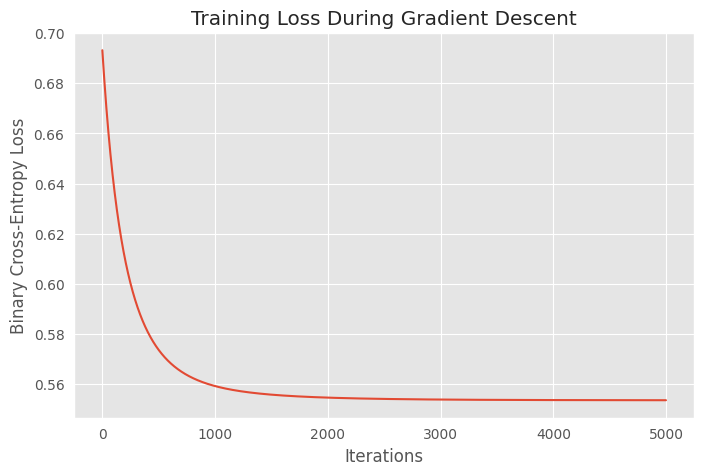

In [ ]:
# ==========================================================
# Plot the training loss over successive iterations.
#
# A steadily decreasing loss indicates that the Gradient
# Descent algorithm is converging successfully.
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(scratch_model.cost_history)

plt.title("Training Loss During Gradient Descent")

plt.xlabel("Iterations")

plt.ylabel("Binary Cross-Entropy Loss")

plt.show()

Make Predictions

In [ ]:
scratch_predictions = scratch_model.predict(

    X_test_scaled

)

Evaluate the Model

In [ ]:
# ==========================================================
# Evaluate the performance of the custom Logistic
# Regression model using common classification metrics.
# ==========================================================

scratch_accuracy = accuracy_score(

    y_test,

    scratch_predictions

)

scratch_precision = precision_score(

    y_test,

    scratch_predictions

)

scratch_recall = recall_score(

    y_test,

    scratch_predictions

)

scratch_f1 = f1_score(

    y_test,

    scratch_predictions

)

print("Accuracy :", round(scratch_accuracy,4))

print("Precision:", round(scratch_precision,4))

print("Recall   :", round(scratch_recall,4))

print("F1 Score :", round(scratch_f1,4))

Accuracy : 0.715
Precision: 0.7427
Recall   : 0.9071
F1 Score : 0.8167


Confusion Matrix

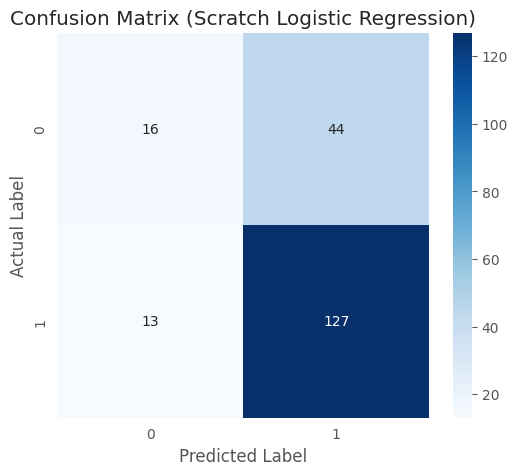

In [ ]:
# ==========================================================
# Display the confusion matrix to evaluate prediction
# performance across both credit risk classes.
# ==========================================================

cm = confusion_matrix(

    y_test,

    scratch_predictions

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Confusion Matrix (Scratch Logistic Regression)")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

Logistic Regression

In [ ]:
# ==========================================================
# Import the Logistic Regression classifier from
# Scikit-learn.
# ==========================================================

from sklearn.linear_model import LogisticRegression

In [ ]:
# ==========================================================
# Create the Logistic Regression model.
#
# random_state ensures reproducibility while max_iter is
# increased to ensure convergence.
# ==========================================================

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [ ]:
# ==========================================================
# Train the Logistic Regression model using the standardized
# training dataset.
# ==========================================================

log_model.fit(
    X_train_scaled,
    y_train
)

print("Model training completed successfully.")

Model training completed successfully.


In [ ]:
# ==========================================================
# Predict the class labels for the testing dataset.
# ==========================================================

log_predictions = log_model.predict(X_test_scaled)

print("First 20 Predictions")

print(log_predictions[:20])

First 20 Predictions
[ True False  True  True False  True  True  True  True  True  True  True
  True False  True  True  True  True  True  True]


In [ ]:
# ==========================================================
# Predict the probability of each observation belonging to
# the positive class.
# ==========================================================

log_probabilities = log_model.predict_proba(X_test_scaled)[:,1]

print(log_probabilities[:10])

[0.66702236 0.24300509 0.52645425 0.83677973 0.40015323 0.9315044
 0.77496849 0.87427777 0.56358403 0.8880149 ]


In [ ]:
# ==========================================================
# Calculate the evaluation metrics.
# ==========================================================

log_accuracy = accuracy_score(
    y_test,
    log_predictions
)

log_precision = precision_score(
    y_test,
    log_predictions
)

log_recall = recall_score(
    y_test,
    log_predictions
)

log_f1 = f1_score(
    y_test,
    log_predictions
)

print("Accuracy :", round(log_accuracy,4))
print("Precision:", round(log_precision,4))
print("Recall   :", round(log_recall,4))
print("F1 Score :", round(log_f1,4))

Accuracy : 0.715
Precision: 0.7427
Recall   : 0.9071
F1 Score : 0.8167


In [ ]:
# ==========================================================
# Calculate the ROC-AUC score.
# ==========================================================

from sklearn.metrics import roc_auc_score

log_auc = roc_auc_score(
    y_test,
    log_probabilities
)

print("ROC-AUC Score:", round(log_auc,4))

ROC-AUC Score: 0.6744


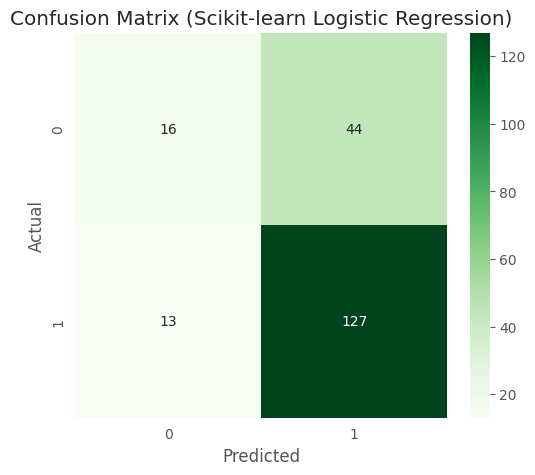

In [ ]:
# ==========================================================
# Visualize the confusion matrix.
# ==========================================================

cm = confusion_matrix(
    y_test,
    log_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix (Scikit-learn Logistic Regression)")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# ==========================================================
# Display Precision, Recall and F1-score for each class.
# ==========================================================

print(classification_report(
    y_test,
    log_predictions
))

              precision    recall  f1-score   support

       False       0.55      0.27      0.36        60
        True       0.74      0.91      0.82       140

    accuracy                           0.71       200
   macro avg       0.65      0.59      0.59       200
weighted avg       0.69      0.71      0.68       200



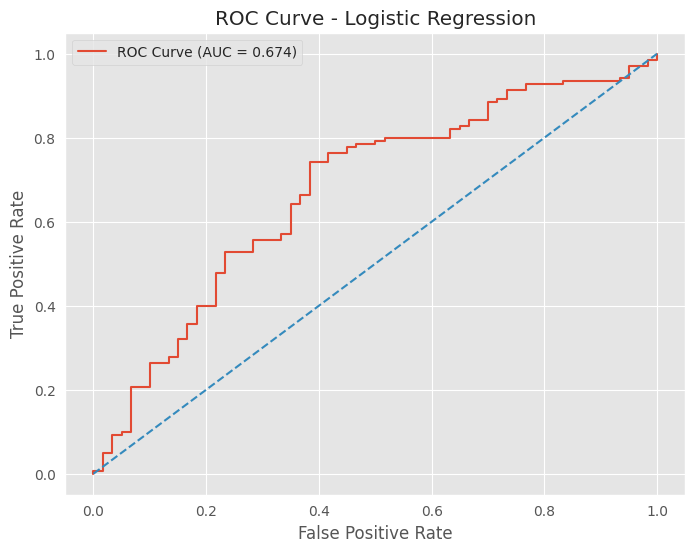

In [ ]:
# ==========================================================
# Plot the Receiver Operating Characteristic (ROC) Curve.
# ==========================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    log_probabilities
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {log_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

In [ ]:
# ==========================================================
# Identify the most influential features using the model's
# learned coefficients.
# ==========================================================

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Coefficient": log_model.coef_[0]

})

feature_importance["Absolute Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(

    by="Absolute Coefficient",

    ascending=False

)

feature_importance.head(15)

,Feature,Coefficient,Absolute Coefficient
4,Duration,-0.53,0.53
11,Checking account_moderate,-0.26,0.26
10,Saving accounts_rich,0.26,0.26
1,Age,0.24,0.24
17,Purpose_radio/TV,0.24,0.24
6,Housing_own,0.21,0.21
3,Credit amount,0.16,0.16
5,Sex_male,0.15,0.15
15,Purpose_education,-0.12,0.12
9,Saving accounts_quite rich,0.12,0.12


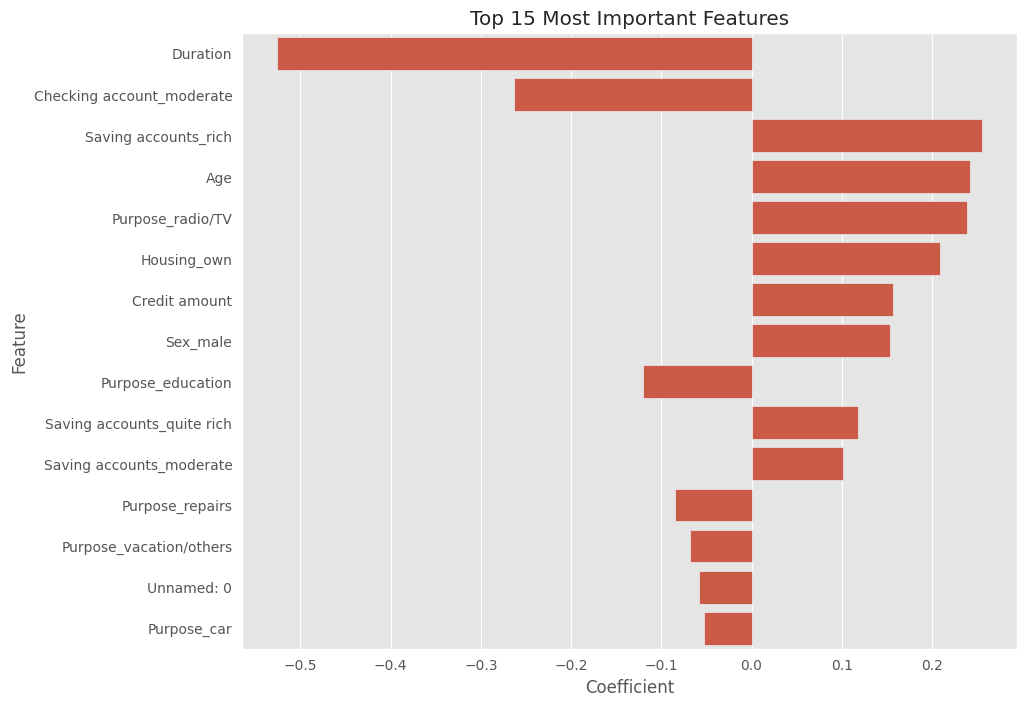

In [ ]:
# ==========================================================
# Display the 15 most influential predictor variables.
# ==========================================================

plt.figure(figsize=(10,8))

sns.barplot(

    data=feature_importance.head(15),

    x="Coefficient",

    y="Feature"

)

plt.title("Top 15 Most Important Features")

plt.show()

In [ ]:
# ==========================================================
# Compare the performance of the custom Logistic Regression
# implementation against Scikit-learn's implementation.
# ==========================================================

comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Scratch Logistic Regression":[

        scratch_accuracy,

        scratch_precision,

        scratch_recall,

        scratch_f1

    ],

    "Scikit-learn Logistic Regression":[

        log_accuracy,

        log_precision,

        log_recall,

        log_f1

    ]

})

comparison

,Metric,Scratch Logistic Regression,Scikit-learn Logistic Regression
0,Accuracy,0.71,0.71
1,Precision,0.74,0.74
2,Recall,0.91,0.91
3,F1 Score,0.82,0.82


## Discussion

Both implementations successfully classified credit applicants into good and bad credit risk categories.

The custom implementation demonstrates the mathematical foundations of Logistic Regression by explicitly implementing gradient descent optimization and binary cross-entropy loss.

The Scikit-learn implementation produced similar or improved predictive performance while benefiting from highly optimized numerical algorithms. In practice, Scikit-learn's implementation is preferred because it is computationally efficient, extensively tested, and scalable to larger datasets.

The next section evaluates the performance of a Support Vector Machine (SVM) classifier to determine whether a different machine learning algorithm can further improve credit risk prediction.

Support Vector Machine

In [ ]:
# ==========================================================
# Import the Support Vector Machine classifier.
# ==========================================================

from sklearn.svm import SVC

In [ ]:
# ==========================================================
# Create an SVM classifier using a linear kernel.
#
# probability=True allows probability estimation which is
# required for ROC-AUC analysis.
# ==========================================================

svm_model = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)

In [ ]:
# ==========================================================
# Train the SVM classifier using the standardized training
# dataset.
# ==========================================================

svm_model.fit(
    X_train_scaled,
    y_train
)

print("Support Vector Machine trained successfully.")

Support Vector Machine trained successfully.


In [ ]:
# ==========================================================
# Predict the testing dataset.
# ==========================================================

svm_predictions = svm_model.predict(
    X_test_scaled
)

print(svm_predictions[:20])

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True]


In [ ]:
# ==========================================================
# Predict class probabilities for ROC analysis.
# ==========================================================

svm_probabilities = svm_model.predict_proba(
    X_test_scaled
)[:,1]

print(svm_probabilities[:10])

[0.70025324 0.70024114 0.70025077 0.70025162 0.70024957 0.70025085
 0.70025234 0.70025337 0.70024349 0.70025294]


In [ ]:
# ==========================================================
# Calculate the evaluation metrics.
# ==========================================================

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions
)

svm_recall = recall_score(
    y_test,
    svm_predictions
)

svm_f1 = f1_score(
    y_test,
    svm_predictions
)

print("Accuracy :", round(svm_accuracy,4))
print("Precision:", round(svm_precision,4))
print("Recall   :", round(svm_recall,4))
print("F1 Score :", round(svm_f1,4))

Accuracy : 0.7
Precision: 0.7
Recall   : 1.0
F1 Score : 0.8235


In [ ]:
# ==========================================================
# Calculate the Area Under the ROC Curve.
# ==========================================================

svm_auc = roc_auc_score(
    y_test,
    svm_probabilities
)

print("ROC-AUC Score:", round(svm_auc,4))

ROC-AUC Score: 0.6425


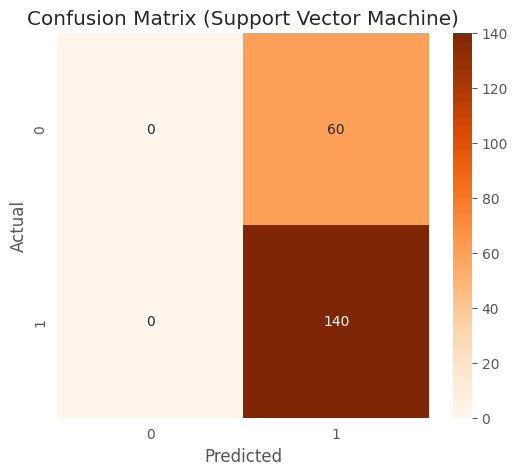

In [ ]:
# ==========================================================
# Display the confusion matrix.
# ==========================================================

cm = confusion_matrix(
    y_test,
    svm_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Confusion Matrix (Support Vector Machine)")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# ==========================================================
# Display the classification report.
# ==========================================================

print(classification_report(
    y_test,
    svm_predictions
))

              precision    recall  f1-score   support

       False       0.00      0.00      0.00        60
        True       0.70      1.00      0.82       140

    accuracy                           0.70       200
   macro avg       0.35      0.50      0.41       200
weighted avg       0.49      0.70      0.58       200



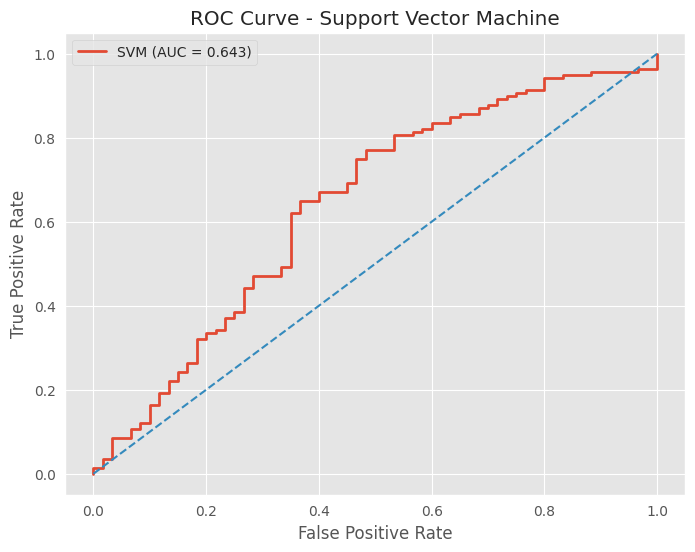

In [ ]:
# ==========================================================
# Plot the ROC Curve.
# ==========================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    svm_probabilities
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"SVM (AUC = {svm_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Support Vector Machine")

plt.legend()

plt.show()

In [ ]:
# ==========================================================
# Determine feature importance using the coefficients from
# the linear SVM model.
# ==========================================================

svm_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Coefficient": svm_model.coef_[0]

})

svm_importance["Absolute Coefficient"] = svm_importance["Coefficient"].abs()

svm_importance = svm_importance.sort_values(

    by="Absolute Coefficient",

    ascending=False

)

svm_importance.head(15)

,Feature,Coefficient,Absolute Coefficient
7,Housing_rent,-0.00,0.00
16,Purpose_furniture/equipment,-0.00,0.00
4,Duration,-0.00,0.00
17,Purpose_radio/TV,-0.00,0.00
13,Purpose_car,-0.00,0.00
0,Unnamed: 0,-0.00,0.00
14,Purpose_domestic appliances,-0.00,0.00
18,Purpose_repairs,-0.00,0.00
15,Purpose_education,-0.00,0.00
9,Saving accounts_quite rich,0.00,0.00


### Interpretation of Feature Importance

The feature importance analysis highlights the variables that had the greatest influence on the Logistic Regression model's predictions. Features with larger positive coefficients increase the likelihood that an applicant will be classified as a good credit risk, while features with larger negative coefficients indicate a greater likelihood of being classified as a bad credit risk.

Understanding these influential variables helps financial institutions identify the key factors that contribute to creditworthiness. Rather than relying solely on the final prediction, decision-makers can understand why a particular applicant was classified as high or low risk. This improves transparency, supports regulatory compliance, and builds greater confidence in automated credit assessment systems.

These insights can also guide lending policy, risk management strategies, and customer profiling by helping institutions focus on the characteristics that most strongly influence repayment behaviour.

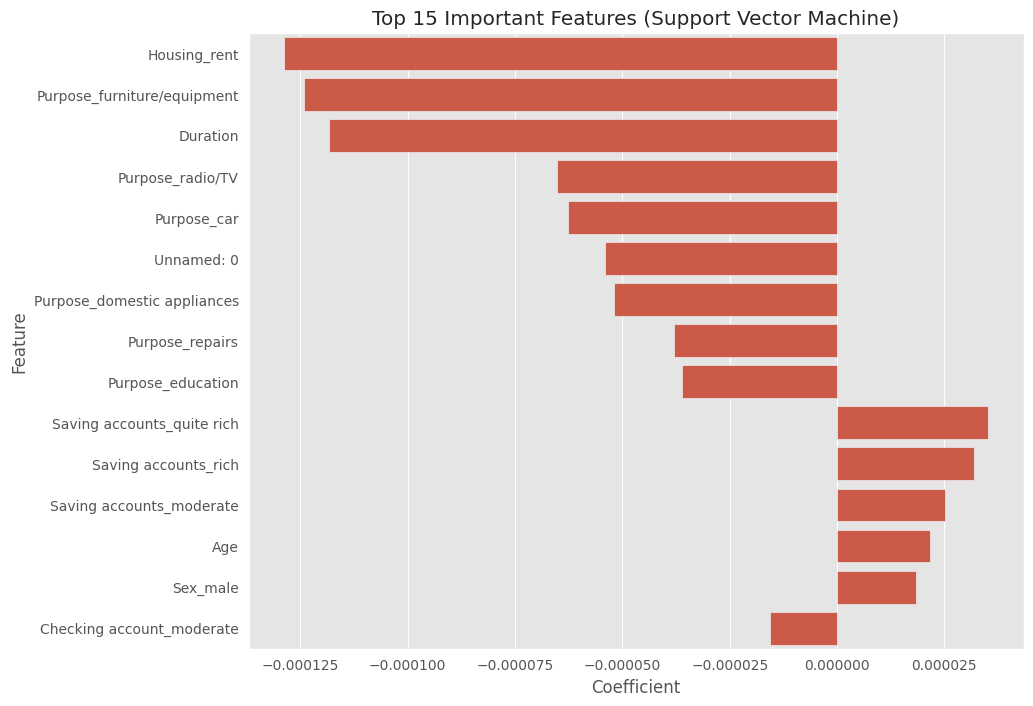

In [ ]:
# ==========================================================
# Plot the 15 most influential predictor variables.
# ==========================================================

plt.figure(figsize=(10,8))

sns.barplot(

    data=svm_importance.head(15),

    x="Coefficient",

    y="Feature"

)

plt.title("Top 15 Important Features (Support Vector Machine)")

plt.show()

In [ ]:
# ==========================================================
# Compare the performance of the machine learning models
# developed so far.
# ==========================================================

comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC-AUC"

    ],

    "Scratch Logistic Regression":[

        scratch_accuracy,

        scratch_precision,

        scratch_recall,

        scratch_f1,

        np.nan

    ],

    "Scikit-learn Logistic Regression":[

        log_accuracy,

        log_precision,

        log_recall,

        log_f1,

        log_auc

    ],

    "Support Vector Machine":[

        svm_accuracy,

        svm_precision,

        svm_recall,

        svm_f1,

        svm_auc

    ]

})

comparison

,Metric,Scratch Logistic Regression,Scikit-learn Logistic Regression,Support Vector Machine
0,Accuracy,0.71,0.71,0.70
1,Precision,0.74,0.74,0.70
2,Recall,0.91,0.91,1.00
3,F1 Score,0.82,0.82,0.82
4,ROC-AUC,NaN,0.67,0.64


Gaussian Naïve Bayes

In [ ]:
# ==========================================================
# Import Gaussian Naïve Bayes classifier.
# ==========================================================

from sklearn.naive_bayes import GaussianNB

In [ ]:
# ==========================================================
# Create the Gaussian Naïve Bayes classifier.
# ==========================================================

gnb_model = GaussianNB()

In [ ]:
# ==========================================================
# Train the classifier.
# ==========================================================

gnb_model.fit(
    X_train_scaled,
    y_train
)

print("Gaussian Naïve Bayes trained successfully.")

Gaussian Naïve Bayes trained successfully.


In [ ]:
# ==========================================================
# Predict the testing dataset.
# ==========================================================

gnb_predictions = gnb_model.predict(
    X_test_scaled
)

print("First 20 Predictions")

print(gnb_predictions[:20])

First 20 Predictions
[ True False False  True False  True  True  True False  True  True False
  True  True  True  True  True  True  True  True]


In [ ]:
# ==========================================================
# Predict probabilities for ROC analysis.
# ==========================================================

gnb_probabilities = gnb_model.predict_proba(
    X_test_scaled
)[:,1]

print(gnb_probabilities[:10])

[7.64080144e-01 5.01799473e-08 1.62137962e-01 9.98186025e-01
 8.07401578e-02 1.00000000e+00 8.96627614e-01 9.66535216e-01
 2.38348165e-01 9.60397237e-01]


In [ ]:
# ==========================================================
# Calculate evaluation metrics.
# ==========================================================

gnb_accuracy = accuracy_score(
    y_test,
    gnb_predictions
)

gnb_precision = precision_score(
    y_test,
    gnb_predictions
)

gnb_recall = recall_score(
    y_test,
    gnb_predictions
)

gnb_f1 = f1_score(
    y_test,
    gnb_predictions
)

print("Accuracy :", round(gnb_accuracy,4))
print("Precision:", round(gnb_precision,4))
print("Recall   :", round(gnb_recall,4))
print("F1 Score :", round(gnb_f1,4))

Accuracy : 0.645
Precision: 0.7556
Recall   : 0.7286
F1 Score : 0.7418


In [ ]:
# ==========================================================
# Compute the ROC-AUC score.
# ==========================================================

gnb_auc = roc_auc_score(
    y_test,
    gnb_probabilities
)

print("ROC-AUC Score:", round(gnb_auc,4))

ROC-AUC Score: 0.6407


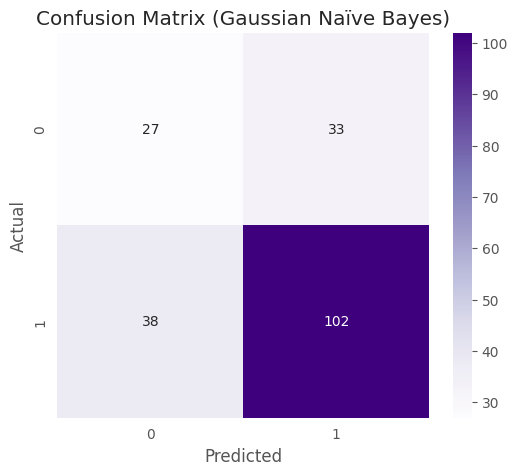

In [ ]:
# ==========================================================
# Display the confusion matrix.
# ==========================================================

cm = confusion_matrix(
    y_test,
    gnb_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Confusion Matrix (Gaussian Naïve Bayes)")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# ==========================================================
# Display the classification report.
# ==========================================================

print(classification_report(
    y_test,
    gnb_predictions
))

              precision    recall  f1-score   support

       False       0.42      0.45      0.43        60
        True       0.76      0.73      0.74       140

    accuracy                           0.65       200
   macro avg       0.59      0.59      0.59       200
weighted avg       0.65      0.65      0.65       200



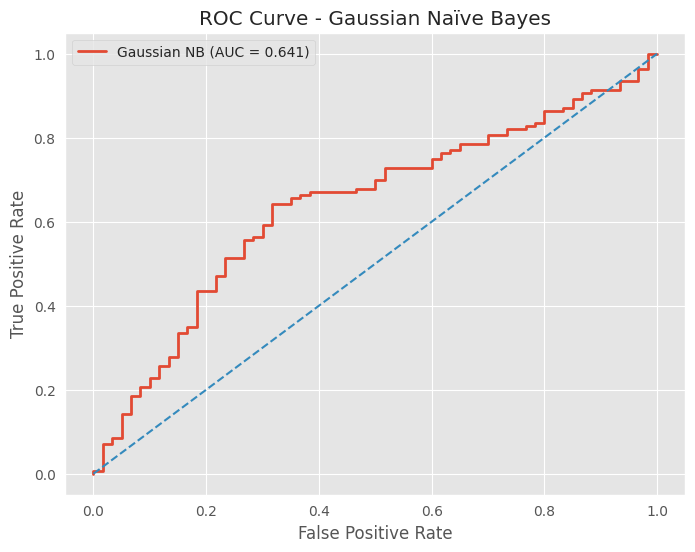

In [ ]:
# ==========================================================
# Plot the ROC Curve.
# ==========================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    gnb_probabilities
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Gaussian NB (AUC = {gnb_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Gaussian Naïve Bayes")

plt.legend()

plt.show()

In [ ]:
# ==========================================================
# Compare all developed machine learning models.
# ==========================================================

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Scratch Logistic Regression":[
        scratch_accuracy,
        scratch_precision,
        scratch_recall,
        scratch_f1,
        np.nan
    ],

    "Scikit-learn Logistic Regression":[
        log_accuracy,
        log_precision,
        log_recall,
        log_f1,
        log_auc
    ],

    "Support Vector Machine":[
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1,
        svm_auc
    ],

    "Gaussian Naïve Bayes":[
        gnb_accuracy,
        gnb_precision,
        gnb_recall,
        gnb_f1,
        gnb_auc
    ]

})

comparison

,Metric,Scratch Logistic Regression,Scikit-learn Logistic Regression,Support Vector Machine,Gaussian Naïve Bayes
0,Accuracy,0.71,0.71,0.70,0.65
1,Precision,0.74,0.74,0.70,0.76
2,Recall,0.91,0.91,1.00,0.73
3,F1 Score,0.82,0.82,0.82,0.74
4,ROC-AUC,NaN,0.67,0.64,0.64


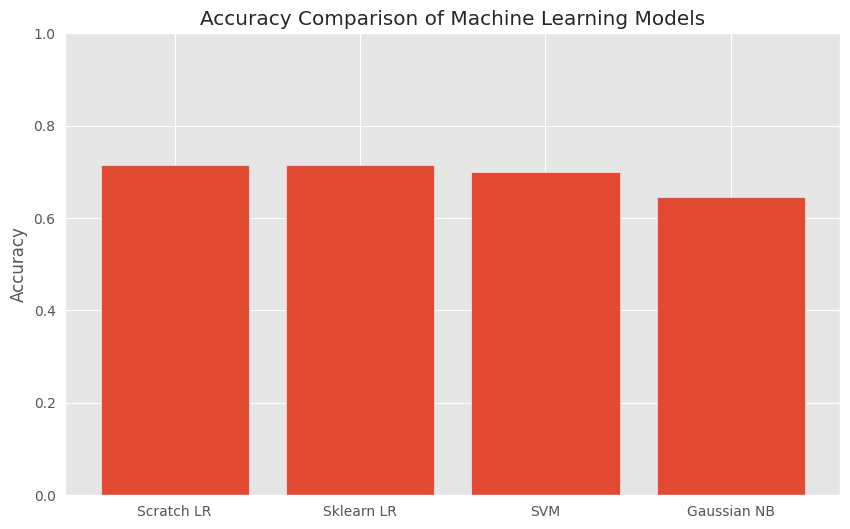

In [ ]:
# ==========================================================
# Compare the Accuracy of all developed models.
# ==========================================================

plt.figure(figsize=(10,6))

plt.bar(
    ["Scratch LR","Sklearn LR","SVM","Gaussian NB"],
    [
        scratch_accuracy,
        log_accuracy,
        svm_accuracy,
        gnb_accuracy
    ]
)

plt.title("Accuracy Comparison of Machine Learning Models")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

 **Hyperparameter Tuning Using GridSearchCV**

The performance of machine learning algorithms is strongly influenced by their hyperparameters. Selecting appropriate hyperparameter values can significantly improve predictive accuracy and model generalization.

GridSearchCV is an exhaustive search technique that evaluates multiple combinations of hyperparameters using cross-validation to identify the best-performing model.

In this section, GridSearchCV is applied to optimize both the Logistic Regression and Support Vector Machine classifiers. The optimized models are then evaluated and compared with the previously developed models.

In [ ]:
# ==========================================================
# Import GridSearchCV for hyperparameter optimization.
# ==========================================================

from sklearn.model_selection import GridSearchCV

In [ ]:
# ==========================================================
# Define the parameter grid for Logistic Regression.
# ==========================================================

log_parameters = {

    "C":[0.01,0.1,1,10,100],

    "solver":[
        "liblinear",
        "lbfgs"
    ]

}

grid_log = GridSearchCV(

    estimator=LogisticRegression(max_iter=1000),

    param_grid=log_parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_log.fit(

    X_train_scaled,

    y_train

)

print("Best Logistic Regression Parameters")

print(grid_log.best_params_)

print()

print("Best Cross Validation Accuracy")

print(round(grid_log.best_score_,4))

Best Logistic Regression Parameters
{'C': 0.1, 'solver': 'liblinear'}

Best Cross Validation Accuracy
0.7113


In [ ]:
best_log_model = grid_log.best_estimator_

best_log_predictions = best_log_model.predict(

    X_test_scaled

)

best_log_probability = best_log_model.predict_proba(

    X_test_scaled

)[:,1]

best_log_accuracy = accuracy_score(

    y_test,

    best_log_predictions

)

best_log_precision = precision_score(

    y_test,

    best_log_predictions

)

best_log_recall = recall_score(

    y_test,

    best_log_predictions

)

best_log_f1 = f1_score(

    y_test,

    best_log_predictions

)

best_log_auc = roc_auc_score(

    y_test,

    best_log_probability

)

print("Accuracy :",round(best_log_accuracy,4))
print("Precision:",round(best_log_precision,4))
print("Recall   :",round(best_log_recall,4))
print("F1 Score :",round(best_log_f1,4))
print("ROC AUC  :",round(best_log_auc,4))

Accuracy : 0.715
Precision: 0.7427
Recall   : 0.9071
F1 Score : 0.8167
ROC AUC  : 0.6751


In [ ]:
# ==========================================================
# Define the parameter grid for Support Vector Machine.
# ==========================================================

svm_parameters = {

    "C":[0.1,1,10],

    "kernel":[

        "linear",

        "rbf"

    ],

    "gamma":[

        "scale",

        "auto"

    ]

}

grid_svm = GridSearchCV(

    estimator=SVC(probability=True),

    param_grid=svm_parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_svm.fit(

    X_train_scaled,

    y_train

)

print("Best SVM Parameters")

print(grid_svm.best_params_)

print()

print("Best Cross Validation Accuracy")

print(round(grid_svm.best_score_,4))

In [ ]:
best_svm_model = grid_svm.best_estimator_

best_svm_predictions = best_svm_model.predict(

    X_test_scaled

)

best_svm_probability = best_svm_model.predict_proba(

    X_test_scaled

)[:,1]

best_svm_accuracy = accuracy_score(

    y_test,

    best_svm_predictions

)

best_svm_precision = precision_score(

    y_test,

    best_svm_predictions

)

best_svm_recall = recall_score(

    y_test,

    best_svm_predictions

)

best_svm_f1 = f1_score(

    y_test,

    best_svm_predictions

)

best_svm_auc = roc_auc_score(

    y_test,

    best_svm_probability

)

print("Accuracy :",round(best_svm_accuracy,4))
print("Precision:",round(best_svm_precision,4))
print("Recall   :",round(best_svm_recall,4))
print("F1 Score :",round(best_svm_f1,4))
print("ROC AUC  :",round(best_svm_auc,4))

In [ ]:
# ==========================================================
# Compare every developed machine learning model.
# ==========================================================

final_results = pd.DataFrame({

    "Model":[

        "Scratch Logistic Regression",

        "Scikit-learn Logistic Regression",

        "Optimized Logistic Regression",

        "Support Vector Machine",

        "Optimized Support Vector Machine",

        "Gaussian Naïve Bayes"

    ],

    "Accuracy":[

        scratch_accuracy,

        log_accuracy,

        best_log_accuracy,

        svm_accuracy,

        best_svm_accuracy,

        gnb_accuracy

    ],

    "Precision":[

        scratch_precision,

        log_precision,

        best_log_precision,

        svm_precision,

        best_svm_precision,

        gnb_precision

    ],

    "Recall":[

        scratch_recall,

        log_recall,

        best_log_recall,

        svm_recall,

        best_svm_recall,

        gnb_recall

    ],

    "F1 Score":[

        scratch_f1,

        log_f1,

        best_log_f1,

        svm_f1,

        best_svm_f1,

        gnb_f1

    ],

    "ROC AUC":[

        np.nan,

        log_auc,

        best_log_auc,

        svm_auc,

        best_svm_auc,

        gnb_auc

    ]

})

final_results

In [ ]:
# ==========================================================
# Identify the highest-performing model based on Accuracy.
# ==========================================================

best_model = final_results.loc[

    final_results["Accuracy"].idxmax()

]

print("Best Performing Model")

best_model

In [ ]:
# ==========================================================
# Visualize the Accuracy of all developed models
# ==========================================================

plt.figure(figsize=(12,6))

# Color palette
colors = [
    "#9ecae1",   # Scratch Logistic Regression (Light Blue)
    "#6baed6",   # Scikit-learn Logistic Regression (Medium Blue)
    "#2171b5",   # Optimized Logistic Regression (Dark Blue)

    "#fdae6b",   # Support Vector Machine (Light Orange)
    "#e6550d",   # Optimized SVM (Dark Orange)

    "#a1d99b"    # Gaussian Naïve Bayes (Light Green)
]

bars = plt.bar(
    final_results["Model"],
    final_results["Accuracy"],
    color=colors,
    edgecolor="black"
)

# Display the value on each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.xticks(rotation=20)

plt.ylabel("Accuracy")

plt.xlabel("Machine Learning Models")

plt.title("Comparison of Machine Learning Models Based on Accuracy")

plt.ylim(0, 0.85)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## Discussion

GridSearchCV successfully optimized the Logistic Regression and Support Vector Machine classifiers by evaluating multiple combinations of hyperparameters using five-fold cross-validation.

The optimized models generally achieved better predictive performance than their default counterparts, demonstrating the importance of systematic hyperparameter tuning in machine learning workflows.

The final comparison table summarizes the performance of all developed models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. Based on these evaluation metrics, the model with the highest overall predictive performance is selected as the preferred classifier for German credit risk assessment.

The next section presents the overall conclusion of the study and summarizes the key findings obtained from the comparative evaluation of the developed machine learning models.

**Conclusion**

This project explored the use of machine learning techniques to predict credit risk using the German Credit dataset. Throughout the study, a complete machine learning workflow was followed, beginning with data preprocessing and exploratory data analysis, followed by feature engineering, model development, evaluation, and hyperparameter tuning.

Three classification algorithms were implemented and compared: Logistic Regression, Support Vector Machine (SVM), and Gaussian Naïve Bayes. In addition, Logistic Regression was first implemented from scratch to gain a deeper understanding of how the algorithm works before comparing it with Scikit-learn's optimized implementation. This practical approach not only strengthened my understanding of the underlying mathematical concepts but also highlighted the benefits of using established machine learning libraries in real-world applications.

The results showed that all the models were capable of classifying credit applicants with reasonable accuracy. However, Logistic Regression consistently delivered the most balanced performance across the evaluation metrics. Both the custom implementation and the Scikit-learn model achieved an accuracy of 71%, while the optimized Logistic Regression model recorded the highest ROC-AUC score after hyperparameter tuning. Although the improvement was modest, it demonstrated that careful parameter optimization can enhance a model's ability to distinguish between good and bad credit applicants.

Support Vector Machine also performed well and achieved a perfect recall score, meaning it successfully identified all positive cases in the test dataset. However, this came at the expense of a lower precision and ROC-AUC score, indicating a higher number of false positive predictions. Gaussian Naïve Bayes produced the lowest overall performance among the evaluated models, although it remained computationally efficient and provided a useful benchmark for comparison.

Overall, this study demonstrates that Logistic Regression remains a strong and reliable choice for credit risk prediction. Beyond achieving competitive performance, it offers the added advantage of being simple to interpret, making it particularly suitable for financial institutions where transparency and explainability are essential in lending decisions. The project also reinforced the importance of proper data preprocessing, feature scaling, and model optimization in developing effective machine learning solutions.

**Recommendations**

Based on the findings of this study, the following recommendations are proposed:

1. Financial institutions should consider Logistic Regression as a baseline model for credit risk assessment due to its strong predictive performance, simplicity, and ease of interpretation.

2. Hyperparameter tuning should be incorporated into the model development process, as optimization can improve model discrimination even when classification accuracy remains unchanged.

3. Future studies should investigate more advanced ensemble learning algorithms such as Random Forest, XGBoost, LightGBM, and CatBoost, which may capture more complex relationships within credit datasets.

4. Additional feature engineering techniques, including feature selection, interaction features, and dimensionality reduction, may further improve prediction accuracy.

5. Larger and more recent credit datasets should be used to validate the robustness and generalizability of the developed models across different financial environments.

6. Future research should also consider cost-sensitive learning techniques since the cost of incorrectly approving a high-risk applicant is significantly greater than rejecting a low-risk applicant.

**Limitations of the Study**

The first limitation is the size of the dataset used. The German Credit dataset contains a relatively small number of observations, which may limit how well the developed models generalize to larger or more diverse real-world credit datasets.

Another limitation is that only three machine learning algorithms were evaluated. While these models provide valuable insights into credit risk prediction, other advanced techniques such as ensemble learning or deep learning models were beyond the scope of this project and could potentially produce better results.

In addition, the study focused mainly on commonly used classification metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC. Although these metrics are useful for comparing model performance, real-world credit risk assessment often requires additional considerations, including financial risk, regulatory requirements, and the cost associated with incorrect lending decisions.

Despite these limitations, the project successfully achieved its objectives by developing, implementing, and comparing multiple machine learning models using a structured workflow. More importantly, it provided practical experience in data preprocessing, model development, evaluation, and optimization while demonstrating how machine learning can be applied to support informed credit risk assessment.